In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import pickle

#plt.rcParams.update({
#    "text.usetex": True,
#    "font.family": "serif",
#    "font.serif": ["Computer Modern Roman"],
#})

In [11]:
with open("../data/processed_data/wafer_data_caleb_fit.pkl", "rb") as f:
    wafer_data = pickle.load(f)

with open("../data/processed_data/wafer_fit_results_caleb_fit.pkl", "rb") as f:
    wafer_fit_results = pickle.load(f)

with open("../data/processed_data/wafer_fit_summary_caleb_fit.pkl", "rb") as f:
    wafer_fit_summary = pickle.load(f)

In [12]:
def invQ_const_model(T_mK, log10_invQ0):
    return 10.0**log10_invQ0 * np.ones_like(T_mK, dtype=float)
def invQ_activation_model(T_mK, log10_invQ0, log10_Aact, Tact_K):
    return (
        10.0**log10_invQ0
        + 10.0**log10_Aact * activated_shape(T_mK, Tact_K)
    )
def activated_shape(T_mK, Tact_K):
    T_K = np.asarray(T_mK, dtype=float) * 1e-3
    return np.exp(-Tact_K / np.maximum(T_K, 1e-12))

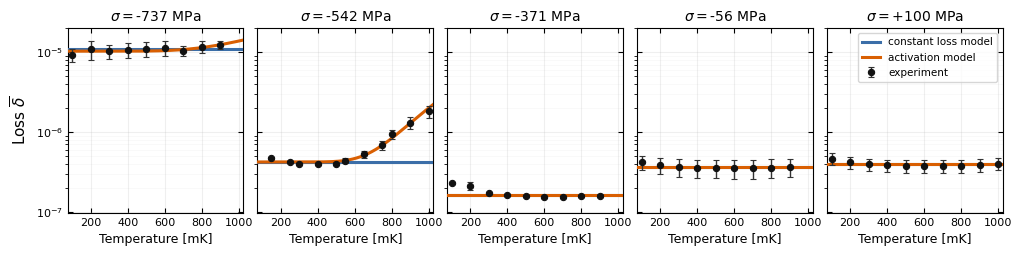

In [13]:
def plot_wafer_activation_fits_paper(
    wafer_data,
    fit_results,
    sample_order=None,
    figsize=(10, 5*.66),
    savepath=None,
):
    if sample_order is None:
        sample_order = sorted(
            fit_results.keys(),
            key=lambda s: wafer_data[s]["stress"]
        )

    # More polished, colorblind-friendly-ish palette
    color_const = "#3B6EA8"   # muted blue
    color_act   = "#D95F02"   # burnt orange
    color_data  = "#111111"
    color_err   = "#333333"

    n = len(sample_order)

    fig, axs = plt.subplots(
        1, n,
        figsize=figsize,
        sharey=True,
        constrained_layout=False,
    )

    if n == 1:
        axs = [axs]

    # Common y-limits
    all_y = []
    all_yerr = []
    for sample in sample_order:
        fit = fit_results[sample]
        all_y.extend(fit["y"])
        all_yerr.extend(fit["yerr"])

    all_y = np.asarray(all_y, dtype=float)
    all_yerr = np.asarray(all_yerr, dtype=float)

    ymin = np.nanmin(all_y - all_yerr)
    ymax = np.nanmax(all_y + all_yerr)
    ymin = max(ymin * 0.65, 1e-9)
    ymax = ymax * 1.45
    xmin = 75
    xmax = 1025

    for i, sample in enumerate(sample_order):
        ax = axs[i]
        fit = fit_results[sample]
        d = wafer_data[sample]

        T = np.asarray(fit["T"], dtype=float)
        y = np.asarray(fit["y"], dtype=float)
        yerr = np.asarray(fit["yerr"], dtype=float)

        Tplot = np.linspace(xmin, xmax, 501)

        y_const = invQ_const_model(Tplot, *fit["constant"]["popt"])
        y_act = invQ_activation_model(Tplot, *fit["activation"]["popt"])

        # Data
        ax.errorbar(
            T, y, yerr=yerr,
            fmt="o",
            ms=4.5,
            color=color_data,
            ecolor=color_err,
            elinewidth=1.0,
            capsize=2.5,
            markeredgewidth=0.8,
            label="experiment",
            zorder=5,
        )

        # Constant model
        ax.plot(
            Tplot, y_const,
            lw=2.2,
            color=color_const,
            label="constant loss model",
            zorder=3
        )

        # Activated model
        ax.plot(
            Tplot, y_act,
            lw=2.2,
            color=color_act,
            label=r"activation model",
            zorder=4
        )

        ax.set_title(
            f"$\\sigma=${d['stress']:+.0f} MPa",
            fontsize=10,
            pad=5
        )

        ax.set_yscale("log")
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(xmin, xmax)
        #ax.set_xlim(np.nanmin(T) - 35, np.nanmax(T) + 35)

        ax.grid(True, which="major", alpha=0.20, lw=0.8)
        ax.grid(True, which="minor", alpha=0.1, lw=0.5)

        ax.tick_params(axis="both", labelsize=8, direction="in", top=True, right=True)

        ax.set_xlabel("Temperature [mK]", fontsize=9)

        if i == 0:
            #a x.set_ylabel(r"$\langle 1/Q_i \rangle_{\rm res}$", fontsize=11)
            ax.set_ylabel(r"Loss $\overline{\delta}$", fontsize=11)
        else:
            ax.tick_params(labelleft=False)

        # Only show legend once
        if i == n - 1:
            ax.legend(
                fontsize=7.5,
                frameon=True,
                loc="best",
                handlelength=1.7,
                borderpad=0.4,
            )

    # fig.suptitle(
    #     r"Wafer-averaged loss: constant background vs activated excess",
    #     y=0.98,
    #     fontsize=13,
    # )

    fig.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.22,
        top=0.78,
        wspace=0.08,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig


fig = plot_wafer_activation_fits_paper(
    wafer_data,
    wafer_fit_results,
    savepath="fig2.png",
)
plt.show()

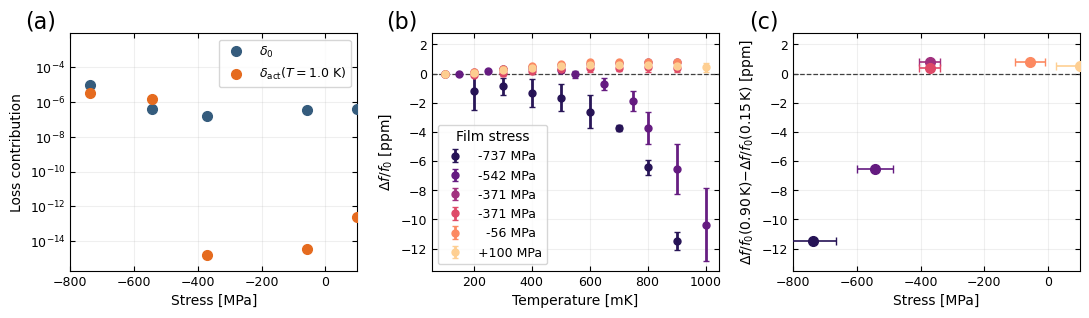

In [14]:
def plot_loss_decomposition_and_freq_shift_3panel(
    wafer_fit_summary,
    wafer_data,
    T_eval=1000.0,
    T_low=150.0,
    T_high=900.0,
    figsize=(11.0, 5*.66),
    cmap_name="magma",
    savepath=None,
):
    color_baseline = "#355C7D"
    color_act = "#E56B1F"
    color_total = "#222222"

    xlim = [-800, 100]
    ylim = [-13.5, 2.75]

    cmap = mpl.colormaps[cmap_name]

    # -------------------------------------------------
    # Loss decomposition
    # -------------------------------------------------
    df = wafer_fit_summary.copy().sort_values("stress")

    stress = df["stress"].to_numpy(dtype=float)
    stress_err = (
        df["stress_err"].to_numpy(dtype=float)
        if "stress_err" in df.columns
        else None
    )

    baseline_loss = 1.0 / df["Q0"].to_numpy(dtype=float)
    Aact = df["Aact"].to_numpy(dtype=float)
    Tact = df["Tact_K"].to_numpy(dtype=float)

    act_loss = Aact * np.exp(-Tact / (T_eval / 1000.0))
    total_loss = baseline_loss + act_loss

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=False)
    ax0, ax1, ax2 = axs

    # =================================================
    # Panel 1: loss decomposition
    # =================================================
    ax0.errorbar(
        stress,
        baseline_loss,
        #xerr=stress_err,
        fmt="o",
        lw=2.2,
        ms=7.0,
        capsize=3,
        color=color_baseline,
        label=r"$\delta_0$",
        zorder=4,
    )

    temp_str = f"{T_eval/1000:.1f} K"
    ax0.errorbar(
        stress,
        act_loss,
        #xerr=stress_err,
        fmt="o",
        lw=2.2,
        ms=7.0,
        capsize=3,
        color=color_act,
        label=r"$\delta_\mathrm{act}(T=$" + temp_str + "$)$",
        zorder=5
    )

    # ax0.errorbar(
    #     stress,
    #     total_loss,
    #     #xerr=stress_err,
    #     fmt="o",
    #     lw=1.8,
    #     ms=7.0,
    #     color=color_total,
    #     label=r"$\delta_0 + \delta_\mathrm{act}(T=$" + temp_str + "$)$",
    #     zorder=6
    # )

    ax0.set_yscale("log")
    ax0.set_xlabel("Stress [MPa]")
    ax0.set_ylabel(r"Loss contribution")
    ax0.set_xlim(xlim)
    ax0.set_ylim(2e-16, 9e-3)
    #ax0.set_title("Empirical loss decomposition", fontsize=12, pad=8)
    ax0.grid(True, which="major", alpha=0.2)
    ax0.grid(True, which="minor", alpha=0.1)
    ax0.legend(fontsize=9, frameon=True, loc="best", handlelength=2.0)

    # =================================================
    # Panel 2: frequency shift curves
    # =================================================
    freq_items = sorted(
        [
            (sample, d)
            for sample, d in wafer_data.items()
            if ("mean_dff" in d) and ("std_dff" in d)
        ],
        key=lambda item: item[1]["stress"],
    )

    colors = cmap(np.linspace(0.15, 0.90, len(freq_items)))

    for color, (sample, d) in zip(colors, freq_items):
        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)
        e = np.asarray(d["std_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y) & np.isfinite(e)

        if np.sum(good) == 0:
            continue

        label = f"{d['stress']:+.0f} MPa"
        if d['stress'] > -100 and d['stress'] < 0:
            label = '  ' + label
        ax1.errorbar(
            T[good],
            1e6 * y[good],
            yerr=1e6 * e[good],
            fmt="o",
            lw=2.0,
            ms=5.0,
            capsize=2.5,
            color=color,
            alpha=0.98,
            label=label,
        )

    ax1.axhline(0, linestyle="--", color="0.25", lw=0.9)
    ax1.set_xlabel("Temperature [mK]")
    ax1.set_ylabel(r"$\Delta f/f_0$ [ppm]")
    ax1.set_ylim(ylim)
    #ax1.set_title("Wafer-averaged frequency shift", fontsize=12, pad=8)
    ax1.grid(True, which="major", alpha=0.2)
    ax1.legend(title="Film stress", fontsize=9, frameon=True, loc="best")

    # =================================================
    # Panel 3: frequency-shift metric vs stress
    # =================================================
    metric_rows = []

    for sample, d in freq_items:
        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y)
        T = T[good]
        y = y[good]

        if len(T) == 0:
            continue

        i_low = np.argmin(np.abs(T - T_low))
        i_high = np.argmin(np.abs(T - T_high))

        metric_rows.append({
            "sample": sample,
            "stress": d["stress"],
            "stress_err": d.get("stress_err", np.nan),
            "delta_dff": y[i_high] - y[i_low],
            "T_low_actual": T[i_low],
            "T_high_actual": T[i_high],
        })

    metric_df = pd.DataFrame(metric_rows).sort_values("stress")

    metric_colors = cmap(np.linspace(0.15, 0.90, len(metric_df)))

    for color, (_, row) in zip(metric_colors, metric_df.iterrows()):
        ax2.errorbar(
            row["stress"],
            1e6 * row["delta_dff"],
            xerr=row["stress_err"],
            fmt="o",
            ms=7,
            capsize=3,
            color=color,
            ecolor=color,
            elinewidth=1.2,
            zorder=4,
        )

    ax2.axhline(0, linestyle="--", color="0.25", lw=0.9)
    ax2.set_xlabel("Stress [MPa]")
    ax2.set_ylabel(
        rf"$\Delta f/f_0({T_high/1000:.2f}\,\mathrm{{K}})$"
        rf"$-\Delta f/f_0({T_low/1000:.2f}\,\mathrm{{K}})$ [ppm]"
    )
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    # ax2.set_title("Frequency-shift metric", fontsize=12, pad=8)
    ax2.grid(True, which="major", alpha=0.2)

    # =================================================
    # Shared styling
    # =================================================
    for ax in axs:
        ax.tick_params(
            axis="both",
            labelsize=9,
            direction="in",
            top=True,
            right=True,
        )

    # fig.subplots_adjust(
    #     left=0.055,
    #     right=0.995,
    #     bottom=0.20,
    #     top=0.86,
    #     wspace=0.34,
    # )

    for ax, label in zip(axs, ['(a)', '(b)', '(c)']):
        ax.text(-0.05, 1.10, label, transform=ax.transAxes,
                fontsize=16,  va='top', ha='right')
    
    plt.tight_layout()
    
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig, metric_df

fig, freq_metric_df = plot_loss_decomposition_and_freq_shift_3panel(
    wafer_fit_summary,
    wafer_data,
    T_eval=1000.0,
    T_low=150.0,
    T_high=900.0,
    cmap_name="magma",
    savepath="fig3.png",
)

plt.show()

In [15]:
def plot_avg_loss_and_freq_shift_3panel(
    wafer_data,
    wafer_fit_results=None,
    T_low=150.0,
    T_high=900.0,
    figsize=(11.0, 5*.66),
    cmap_name="magma",
    savepath=None,
):
    """
    Paper-style 3-panel figure:

      (a) wafer-averaged loss vs temperature
      (b) wafer-averaged frequency shift vs temperature
      (c) frequency-shift metric vs stress

    Uses wafer_fit_results for loss if supplied, otherwise tries to read
    mean loss arrays directly from wafer_data.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    xlim_stress = [-800, 100]
    freq_ylim = [-13.5, 2.75]

    cmap = mpl.colormaps[cmap_name]

    # -------------------------------------------------
    # sample order
    # -------------------------------------------------
    sample_order = sorted(
        wafer_data.keys(),
        key=lambda s: wafer_data[s]["stress"]
    )

    colors = cmap(np.linspace(0.15, 0.90, len(sample_order)))

    fig, axs = plt.subplots(
        1, 3,
        figsize=figsize,
        constrained_layout=False,
    )

    ax0, ax1, ax2 = axs

    # =================================================
    # Panel 1: wafer-averaged loss curves
    # =================================================
    for color, sample in zip(colors, sample_order):

        if wafer_fit_results is not None and sample in wafer_fit_results:
            fit = wafer_fit_results[sample]
            T = np.asarray(fit["T"], dtype=float)
            y = np.asarray(fit["y"], dtype=float)
            e = np.asarray(fit["yerr"], dtype=float)

        else:
            d = wafer_data[sample]

            # flexible fallbacks depending on your wafer_data keys
            T = np.asarray(d["T_mK"], dtype=float)

            if "mean_loss" in d:
                y = np.asarray(d["mean_loss"], dtype=float)
            elif "mean_invQ" in d:
                y = np.asarray(d["mean_invQ"], dtype=float)
            elif "mean_delta" in d:
                y = np.asarray(d["mean_delta"], dtype=float)
            else:
                raise KeyError(
                    f"Could not find averaged loss for {sample}. "
                    "Expected one of: mean_loss, mean_invQ, mean_delta, "
                    "or pass wafer_fit_results."
                )

            if "std_loss" in d:
                e = np.asarray(d["std_loss"], dtype=float)
            elif "std_invQ" in d:
                e = np.asarray(d["std_invQ"], dtype=float)
            elif "std_delta" in d:
                e = np.asarray(d["std_delta"], dtype=float)
            else:
                e = np.zeros_like(y)

        good = np.isfinite(T) & np.isfinite(y) & np.isfinite(e)

        label = f"{wafer_data[sample]['stress']:+.0f} MPa"

        ax0.errorbar(
            T[good],
            y[good],
            yerr=e[good],
            fmt="o",
            lw=1.8,
            ms=4.5,
            capsize=2.5,
            color=color,
            alpha=0.98,
            label=label,
        )

    ax0.set_yscale("log")
    ax0.set_xlabel("Temperature [mK]")
    ax0.set_ylabel(r"Loss $\overline{\delta} = \langle 1/Q_i\rangle_{\rm res}$")
    ax0.grid(True, which="major", alpha=0.2)
    ax0.grid(True, which="minor", alpha=0.1)
    ax0.legend(title="Film stress", fontsize=8, frameon=True, loc="best")

    # =================================================
    # Panel 2: wafer-averaged frequency shift curves
    # =================================================
    freq_items = [
        (sample, wafer_data[sample])
        for sample in sample_order
        if ("mean_dff" in wafer_data[sample]) and ("std_dff" in wafer_data[sample])
    ]

    for color, (sample, d) in zip(colors, freq_items):
        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)
        e = np.asarray(d["std_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y) & np.isfinite(e)

        ax1.errorbar(
            T[good],
            1e6 * y[good],
            yerr=1e6 * e[good],
            fmt="o",
            lw=1.8,
            ms=4.5,
            capsize=2.5,
            color=color,
            alpha=0.98,
            label=f"{d['stress']:+.0f} MPa",
        )

    ax1.axhline(0, linestyle="--", color="0.25", lw=0.9)
    ax1.set_xlabel("Temperature [mK]")
    ax1.set_ylabel(r"$\Delta f/f_0$ [ppm]")
    ax1.set_ylim(freq_ylim)
    ax1.grid(True, which="major", alpha=0.2)

    # =================================================
    # Panel 3: frequency-shift metric vs stress
    # =================================================
    metric_rows = []

    for sample, d in freq_items:
        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y)
        T = T[good]
        y = y[good]

        if len(T) == 0:
            continue

        i_low = np.argmin(np.abs(T - T_low))
        i_high = np.argmin(np.abs(T - T_high))

        metric_rows.append({
            "sample": sample,
            "stress": d["stress"],
            "stress_err": d.get("stress_err", np.nan),
            "delta_dff": y[i_high] - y[i_low],
            "T_low_actual": T[i_low],
            "T_high_actual": T[i_high],
        })

    metric_df = pd.DataFrame(metric_rows).sort_values("stress")

    metric_colors = cmap(np.linspace(0.15, 0.90, len(metric_df)))

    for color, (_, row) in zip(metric_colors, metric_df.iterrows()):
        ax2.errorbar(
            row["stress"],
            1e6 * row["delta_dff"],
            xerr=row["stress_err"],
            fmt="o",
            ms=7,
            capsize=3,
            color=color,
            ecolor=color,
            elinewidth=1.2,
            zorder=4,
        )

    ax2.axhline(0, linestyle="--", color="0.25", lw=0.9)
    ax2.set_xlabel("Stress [MPa]")
    ax2.set_ylabel(
        rf"$\Delta f/f_0({T_high/1000:.2f}\,\mathrm{{K}})$"
        rf"$-\Delta f/f_0({T_low/1000:.2f}\,\mathrm{{K}})$ [ppm]"
    )
    ax2.set_xlim(xlim_stress)
    ax2.set_ylim(freq_ylim)
    ax2.grid(True, which="major", alpha=0.2)

    # =================================================
    # Shared styling
    # =================================================
    for ax in axs:
        ax.tick_params(
            axis="both",
            labelsize=9,
            direction="in",
            top=True,
            right=True,
        )

    for ax, label in zip(axs, ["(a)", "(b)", "(c)"]):
        ax.text(
            -0.05, 1.10, label,
            transform=ax.transAxes,
            fontsize=16,
            va="top",
            ha="right",
        )

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig, metric_df

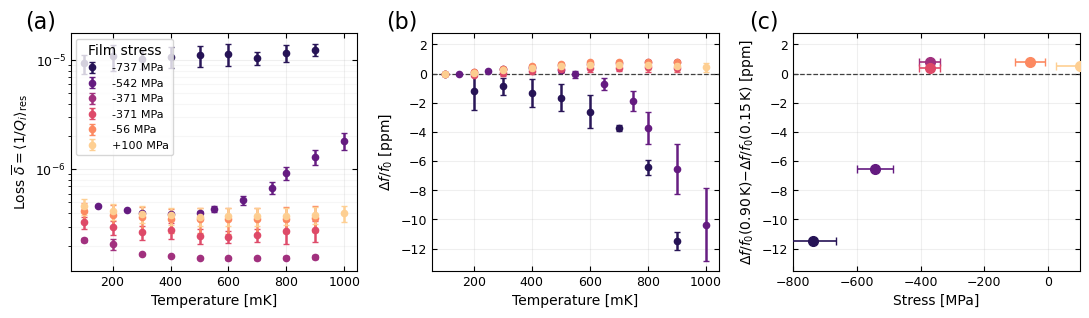

In [16]:
fig, freq_metric_df = plot_avg_loss_and_freq_shift_3panel(
    wafer_data,
    wafer_fit_results=wafer_fit_results,
    T_low=150.0,
    T_high=900.0,
    cmap_name="magma",
    savepath="fig3_new.png",
)

plt.show()

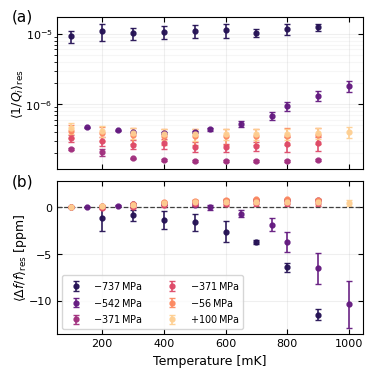

In [21]:
def plot_avg_loss_and_freq_shift_column(
    wafer_data,
    wafer_fit_results=None,
    figsize=(3.4, 4.8),
    cmap_name="magma",
    freq_ylim=(-13.5, 2.75),
    savepath=None
):
    """
    Single-column paper figure:

        (a) wafer-averaged loss
        (b) wafer-averaged frequency shift

    stacked vertically.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    cmap = mpl.colormaps[cmap_name]

    sample_order = sorted(
        wafer_data.keys(),
        key=lambda s: wafer_data[s]["stress"]
    )

    colors = cmap(np.linspace(0.15, 0.90, len(sample_order)))

    fig, axs = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        constrained_layout=False,
    )

    ax0, ax1 = axs

    # =====================================================
    # (a) Wafer-averaged loss
    # =====================================================
    for color, sample in zip(colors, sample_order):

        if wafer_fit_results is not None and sample in wafer_fit_results:
            fit = wafer_fit_results[sample]

            T = np.asarray(fit["T"], dtype=float)
            y = np.asarray(fit["y"], dtype=float)
            e = np.asarray(fit["yerr"], dtype=float)

        else:
            d = wafer_data[sample]

            T = np.asarray(d["T_mK"], dtype=float)

            if "mean_loss" in d:
                y = np.asarray(d["mean_loss"], dtype=float)
            elif "mean_invQ" in d:
                y = np.asarray(d["mean_invQ"], dtype=float)
            elif "mean_delta" in d:
                y = np.asarray(d["mean_delta"], dtype=float)
            else:
                raise KeyError(
                    f"No averaged loss found for {sample}"
                )

            if "std_loss" in d:
                e = np.asarray(d["std_loss"], dtype=float)
            elif "std_invQ" in d:
                e = np.asarray(d["std_invQ"], dtype=float)
            elif "std_delta" in d:
                e = np.asarray(d["std_delta"], dtype=float)
            else:
                e = np.zeros_like(y)

        good = np.isfinite(T) & np.isfinite(y) & np.isfinite(e)

        label = f"{wafer_data[sample]['stress']:+.0f}$\\,$MPa".replace('-', '$-$')

        ax0.errorbar(
            T[good],
            y[good],
            yerr=e[good],
            fmt="o",
            ms=3.5,
            lw=1.2,
            capsize=2,
            color=color,
            alpha=0.95,
            label=label,
        )

    ax0.set_yscale("log")
    ax0.set_ylabel(
        r"$\langle 1/Q_i\rangle_{\rm res}$",
        fontsize=9,
        labelpad=-0.5
    )

    ax0.grid(True, which="major", alpha=0.2)
    ax0.grid(True, which="minor", alpha=0.1)

    # ax0.legend(ncol=2,
    #     #title="Stress",
    #     fontsize=7,
    #     title_fontsize=8,
    #     frameon=True,
    #     loc="center left",
    # )

    # =====================================================
    # (b) Wafer-averaged frequency shift
    # =====================================================
    freq_items = [
        (sample, wafer_data[sample])
        for sample in sample_order
        if ("mean_dff" in wafer_data[sample])
        and ("std_dff" in wafer_data[sample])
    ]

    for color, (sample, d) in zip(colors, freq_items):

        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)
        e = np.asarray(d["std_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y) & np.isfinite(e)
        label = f"{wafer_data[sample]['stress']:+.0f}$\\,$MPa".replace('-', '$-$')

        ax1.errorbar(
            T[good],
            1e6 * y[good],
            yerr=1e6 * e[good],
            fmt="o",
            ms=3.5,
            lw=1.2,
            capsize=2,
            color=color,
            alpha=0.95, label=label
        )

    ax1.axhline(
        0,
        color="0.25",
        lw=0.9,
        ls="--",
    )

    ax1.set_ylim(freq_ylim)

    ax1.set_ylabel(
        r"$\langle \Delta f/f\rangle_{\rm res}$ [ppm]",
        fontsize=9,
        labelpad=0
    )

    ax1.set_xlabel(
        "Temperature [mK]",
        fontsize=9,
    )

    ax1.grid(True, alpha=0.2)
    ax1.legend(ncol=2,
    #title="Stress",
    fontsize=7,
    title_fontsize=8,
    frameon=True, loc='best'
    )

    # =====================================================
    # Shared styling
    # =====================================================
    for ax in axs:

        ax.tick_params(
            axis="both",
            labelsize=8,
            direction="in",
            top=True,
            right=True,
        )

    ax0.text(
        -0.15, .97,
        "(a)",
        transform=ax0.transAxes,
        fontsize=11
    )

    ax1.text(
        -0.15, .97,
        "(b)",
        transform=ax1.transAxes,
        fontsize=11
    )

    fig.subplots_adjust(
        left=0.22,
        right=0.98,
        bottom=0.10,
        top=0.98,
        hspace=0.08,
    )

    if savepath is not None:

        fig.savefig(
            savepath,
            dpi=300,
            bbox_inches="tight",
        )

        if savepath.endswith(".png"):
            fig.savefig(
                savepath, dpi=350,
                bbox_inches="tight",
            )

    # fig.tight_layout()

    return fig

fig = plot_avg_loss_and_freq_shift_column(
    wafer_data,
    wafer_fit_results,
    figsize=(3.35*1.2, 3.*1.2),
    savepath="wafer_average.pdf",
)